# SAXS Tensor Tomography — Method Comparison

Compares four reconstruction methods on the same frogbone dataset, all converted to the
same representation: one scalar volume per q-direction `(K, X, Y, Z)`.

| Section | Method | Library |
|---------|--------|---------|
| 1 | FBP | smartt |
| 2 | NearestNeighbor + LBFGS | mumott |
| 3 | SphericalHarmonics + LBFGS → projected to NN | mumott |
| 4 | GaussianKernels + LBFGS → projected to NN | mumott |
| 5 | Side-by-side comparison + missing-cone visualisation | — |

All mumott reconstructions use the same optimiser settings so comparisons are fair.

In [56]:
import sys
sys.path.insert(0, '/myhome/smartt')

import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

from mumott.data_handling import DataContainer
from mumott.methods.basis_sets import SphericalHarmonics, GaussianKernels, NearestNeighbor
from mumott.methods.projectors import SAXSProjectorCUDA, SAXSProjector
from mumott.methods.residual_calculators import GradientResidualCalculator
from mumott.optimization.loss_functions import SquaredLoss
from mumott.optimization.optimizers import LBFGS
from mumott.optimization.regularizers import Laplacian
from mumott.core.probed_coordinates import ProbedCoordinates

from smartt.saxs_fbp import fibonacci_hemisphere, saxs_fbp_reconstruction, saxs_gd_reconstruction

# ── Parameters ────────────────────────────────────────────────────────────────
DATA_PATH        = '/myhome/data/smartt/shared/frogbone/dataset_qbin_0009.h5'
K                = 30      # number of q-directions (Fibonacci hemisphere)
HALF_SPACE       = 'y'     # y>0 hemisphere to match goniometer frame
LBFGS_MAXITER    = 20
LAPLACIAN_WEIGHT = 1e-1
SH_ELL_MAX       = 6

# ── Cache settings ─────────────────────────────────────────────────────────────
# mumott optimisations are saved as .npy files (keyed by method + K) so they
# can be skipped on subsequent runs.  Set force_reload=True to rerun from scratch.
CACHE_DIR    = pathlib.Path('/myhome/data/smartt/shared/results/saxs_comparison')
force_reload = False

CACHE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Cache directory: {CACHE_DIR}')
print(f'force_reload: {force_reload}')

device: cuda
GPU: NVIDIA A100 80GB PCIe
Cache directory: /myhome/data/smartt/shared/results/saxs_comparison
force_reload: False


In [2]:
dc = DataContainer(DATA_PATH, nonfinite_replacement_value=0)
geometry = dc.geometry

print('data shape    :', dc.data.shape, '  (N, J, K_det, M)')
print('volume_shape  :', geometry.volume_shape)
print('n_projections :', len(dc.projections))

y_directions = fibonacci_hemisphere(K, half_space=HALF_SPACE)
print(f'\ny_directions shape: {y_directions.shape}  (K, 3)')

INFO:Rotation matrices were loaded from the input file.


/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:228: DeprecationWarning: Entry name rotations is deprecated. Use inner_angle instead.
  _deprecated_key_warning('rotations')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:237: DeprecationWarning: Entry name tilts is deprecated. Use outer_angle instead.
  _deprecated_key_warning('tilts')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:247: DeprecationWarning: Entry name rot_mat is deprecated. Use rotation_matrix instead.
  _deprecated_key_warning('rot_mat')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:269: DeprecationWarning: Entry name offset_j is deprecated. Use j_offset instead.
  _deprecated_key_warning('offset_j')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:279: DeprecationWarning: Entry name offset_k is deprecated. Use k_offset instead.
  _deprecated_key_warning('offset_k'

INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
data shape    : (240, 73, 100, 8)   (N, J, K_det, M)
volume_shape  : [65 82 65]
n_projections : 240

y_directions shape: (30, 3)  (K, 3)


## 1. smartt FBP Reconstruction

For each of the K q-directions the scalar sinogram is built via a GPU einsum over the
arc-fraction projection matrix, then inverted with ramp-filtered backprojection (ASTRA BP3D).

In [81]:
ball_threshold = 0.25

recon_fbp, y_dirs, nn_helper = saxs_fbp_reconstruction(
    dc=dc,
    k_fibonacci=K,
    filter_type='hann',
    n_projection_samples=64,
    device=device,
    verbose=True,
    return_matrix=True,
    projection_method='ball',
    ball_threshold=ball_threshold,
    half_space=HALF_SPACE,
)


# recon_fbp, y_dirs, nn_helper = saxs_gd_reconstruction(
#     dc=dc,
#     k_fibonacci=K,
#     n_iterations=300,
#     lr=10,
#     n_projection_samples=64,
#     device=device,
#     verbose=True,
#     return_matrix=True,
#     projection_method="ball",
#     ball_threshold=ball_threshold,
#     half_space=HALF_SPACE,
# )
recon_fbp_np = recon_fbp.cpu().numpy()   # (K, X, Y, Z)
print(f'\nFBP shape  : {recon_fbp_np.shape}')
print(f'value range: [{recon_fbp_np.min():.3e}, {recon_fbp_np.max():.3e}]')

INFO:Building projection matrix on GPU: K=30, n_samples=64, method=ball
INFO:Moving data to cuda...


SAXS FBP: 100%|██████████| 30/30 [00:00<00:00, 51.23dir/s, n_sub=106]



FBP shape  : (30, 65, 82, 65)
value range: [-2.916e+02, 9.805e+02]


## 2. mumott NearestNeighbor Reconstruction

Uses the same K Fibonacci directions as the FBP.  Each coefficient `C[x,y,z,k]` directly
represents the scattering intensity at direction `y_k` — no basis conversion needed.

In [82]:
# Build the shared mumott projector once (fast — geometry setup only).
# Always constructed so it is available if any method needs to optimise.
projector_mumott = (
    SAXSProjector(geometry) if torch.cuda.is_available() else SAXSProjector(geometry)
)

_nn_cache = CACHE_DIR / f'mumott_nn_K{K}.npy'

if not force_reload and _nn_cache.exists():
    print(f'Loading NN coefficients from cache: {_nn_cache}')
    coeffs_nn = np.load(_nn_cache)
else:
    basis_nn = NearestNeighbor(
        directions=y_directions,
        probed_coordinates=geometry.probed_coordinates,
    )
    rc_nn   = GradientResidualCalculator(data_container=dc, basis_set=basis_nn, projector=projector_mumott)
    loss_nn = SquaredLoss(rc_nn)
    loss_nn.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_nn  = LBFGS(loss_nn, maxiter=LBFGS_MAXITER)
    result_nn = opt_nn.optimize()
    coeffs_nn = result_nn['x']                    # (X, Y, Z, K)
    np.save(_nn_cache, coeffs_nn)
    print(f'Saved NN coefficients → {_nn_cache}')

print(f'coeffs_nn shape: {coeffs_nn.shape}')

Loading NN coefficients from cache: /myhome/data/smartt/shared/results/saxs_comparison/mumott_nn_K30.npy
coeffs_nn shape: (65, 82, 65, 30)


In [83]:
recon_nn = np.moveaxis(coeffs_nn, -1, 0)   # (K, X, Y, Z)
print(f'NN reconstruction shape: {recon_nn.shape}')

NN reconstruction shape: (30, 65, 82, 65)


## 3. mumott SphericalHarmonics Reconstruction → projected to NN

Optimises a band-limited SH expansion (`ell_max=6`, C=28 coefficients with Friedel symmetry),
then evaluates it at the K Fibonacci directions to obtain the same `(K, X, Y, Z)` layout.

The evaluation uses the SH basis matrix `B[k,c] = Y_c(y_k)` computed via
`_get_projection_matrix` — the same internal function used by mumott's `generate_map`.

In [84]:
_sh_cache = CACHE_DIR / f'mumott_sh_ell{SH_ELL_MAX}_K{K}.npy'

# basis_sh is always instantiated: it is needed for the transfer step (cell below)
# regardless of whether the coefficients come from cache or from optimisation.
basis_sh = SphericalHarmonics(
    ell_max=SH_ELL_MAX,
    probed_coordinates=geometry.probed_coordinates,
)
print(f'SH basis: ell_max={SH_ELL_MAX}, n_coefficients={len(basis_sh)}')

if not force_reload and _sh_cache.exists():
    print(f'Loading SH coefficients from cache: {_sh_cache}')
    coeffs_sh = np.load(_sh_cache)
else:
    rc_sh   = GradientResidualCalculator(data_container=dc, basis_set=basis_sh, projector=projector_mumott)
    loss_sh = SquaredLoss(rc_sh)
    loss_sh.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_sh  = LBFGS(loss_sh, maxiter=LBFGS_MAXITER)
    result_sh = opt_sh.optimize()
    coeffs_sh = result_sh['x']                    # (X, Y, Z, C)
    np.save(_sh_cache, coeffs_sh)
    print(f'Saved SH coefficients → {_sh_cache}')

print(f'coeffs_sh shape: {coeffs_sh.shape}')

SH basis: ell_max=6, n_coefficients=28
Loading SH coefficients from cache: /myhome/data/smartt/shared/results/saxs_comparison/mumott_sh_ell6_K30.npy
coeffs_sh shape: (65, 82, 65, 28)


In [85]:
# Build evaluation matrix: B[k, c] = Y_c(y_k)  shape (K, C)
pc_eval = ProbedCoordinates()
pc_eval.vector = y_directions[:, np.newaxis, np.newaxis, :]   # (K, 1, 1, 3)
eval_sh = basis_sh._get_projection_matrix(pc_eval)[:, 0, 0, :]  # (K, C)

recon_sh  = np.einsum('xyzc, kc -> kxyz', coeffs_sh, eval_sh)  # (K, X, Y, Z)
print(f'SH→NN reconstruction shape: {recon_sh.shape}')

SH→NN reconstruction shape: (30, 65, 82, 65)


## 4. mumott GaussianKernels Reconstruction → projected to NN

Same pipeline as SH but using isotropic Gaussian kernels on the sphere.  The default
`grid_scale=4` places kernels at a Kurihara mesh resolution of ~4 points per 90°.

In [86]:
_gk_cache = CACHE_DIR / f'mumott_gk_K{K}.npy'

basis_gk = GaussianKernels(
    probed_coordinates=geometry.probed_coordinates,
)
print(f'GK basis: n_kernels={len(basis_gk)}')

if not force_reload and _gk_cache.exists():
    print(f'Loading GK coefficients from cache: {_gk_cache}')
    coeffs_gk = np.load(_gk_cache)
else:
    rc_gk   = GradientResidualCalculator(data_container=dc, basis_set=basis_gk, projector=projector_mumott)
    loss_gk = SquaredLoss(rc_gk)
    loss_gk.add_regularizer('laplacian', Laplacian(), regularization_weight=LAPLACIAN_WEIGHT)
    opt_gk  = LBFGS(loss_gk, maxiter=LBFGS_MAXITER)
    result_gk = opt_gk.optimize()
    coeffs_gk = result_gk['x']                    # (X, Y, Z, C_gk)
    np.save(_gk_cache, coeffs_gk)
    print(f'Saved GK coefficients → {_gk_cache}')

print(f'coeffs_gk shape: {coeffs_gk.shape}')

GK basis: n_kernels=50
Loading GK coefficients from cache: /myhome/data/smartt/shared/results/saxs_comparison/mumott_gk_K30.npy
coeffs_gk shape: (65, 82, 65, 50)


In [87]:
eval_gk = basis_gk._get_projection_matrix(pc_eval)[:, 0, 0, :]  # (K, C_gk)
recon_gk  = np.einsum('xyzc, kc -> kxyz', coeffs_gk, eval_gk)  # (K, X, Y, Z)
print(f'GK→NN reconstruction shape: {recon_gk.shape}')

GK→NN reconstruction shape: (30, 65, 82, 65)


## 5. Comparison

All four reconstructions are now in `(K, X, Y, Z)` float32 arrays with the same K Fibonacci
q-directions.  The following panels compare them using the same colour scale.

- **5.1** Mean intensity orthoslices
- **5.2** Single q-direction volume slices
- **5.3** Difference maps relative to FBP
- **5.4** Missing-cone visualisation in Fourier space

In [88]:
reconstructions = {
    'FBP (smartt)':               recon_fbp_np,
    'NearestNeighbor (mumott)':   recon_nn,
    'SphericalHarmonics (mumott)': recon_sh,
    'GaussianKernels (mumott)':   recon_gk,
}

vol_shape = recon_fbp_np.shape[1:]
mid_x, mid_y, mid_z = [s // 2 for s in vol_shape]
print('Volume shape:', vol_shape)
print(f'Central slices: x={mid_x}, y={mid_y}, z={mid_z}')

Volume shape: (65, 82, 65)
Central slices: x=32, y=41, z=32


### 5.1 Mean intensity orthoslices

Colour scale is fixed to the [2nd, 98th] percentile of the FBP mean volume so all panels
are directly comparable.

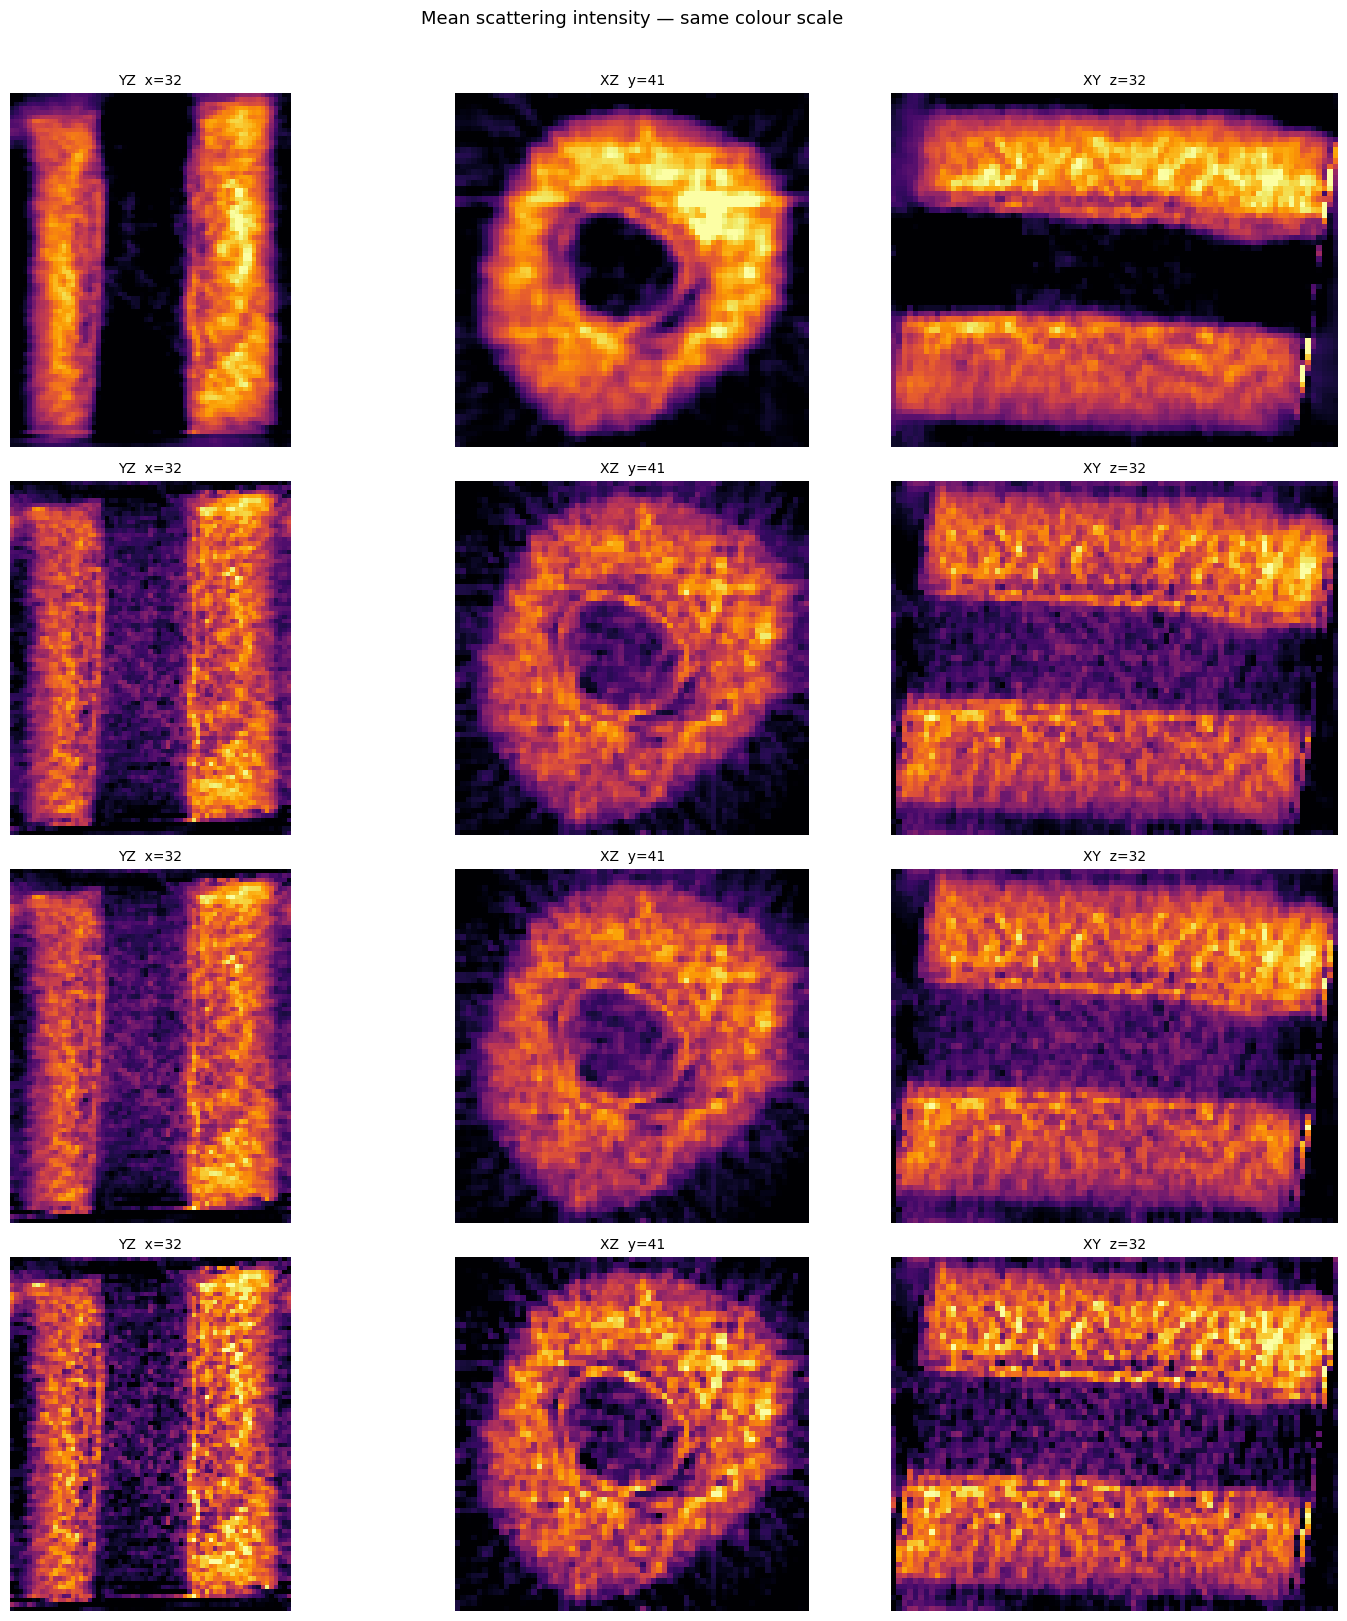

In [89]:
mean_fbp = recon_fbp_np.mean(axis=0)
valid_vals = mean_fbp[mean_fbp > 0]
vmin, vmax = (np.percentile(valid_vals, [2, 98]) if valid_vals.size > 0 else (0.0, 1.0))

n_methods = len(reconstructions)
fig, axes = plt.subplots(n_methods, 3, figsize=(15, 4 * n_methods))

for row, (name, recon) in enumerate(reconstructions.items()):
    mean_vol = recon.mean(axis=0)
    slices   = [mean_vol[mid_x, :, :], mean_vol[:, mid_y, :], mean_vol[:, :, mid_z]]
    titles   = [f'YZ  x={mid_x}', f'XZ  y={mid_y}', f'XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin, vmax=vmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=9)

# plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Mean intensity')
plt.suptitle('Mean scattering intensity — same colour scale', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Single q-direction volume slices

Each panel shows one reconstructed direction k.  Change `K_INSPECT` to explore other directions.

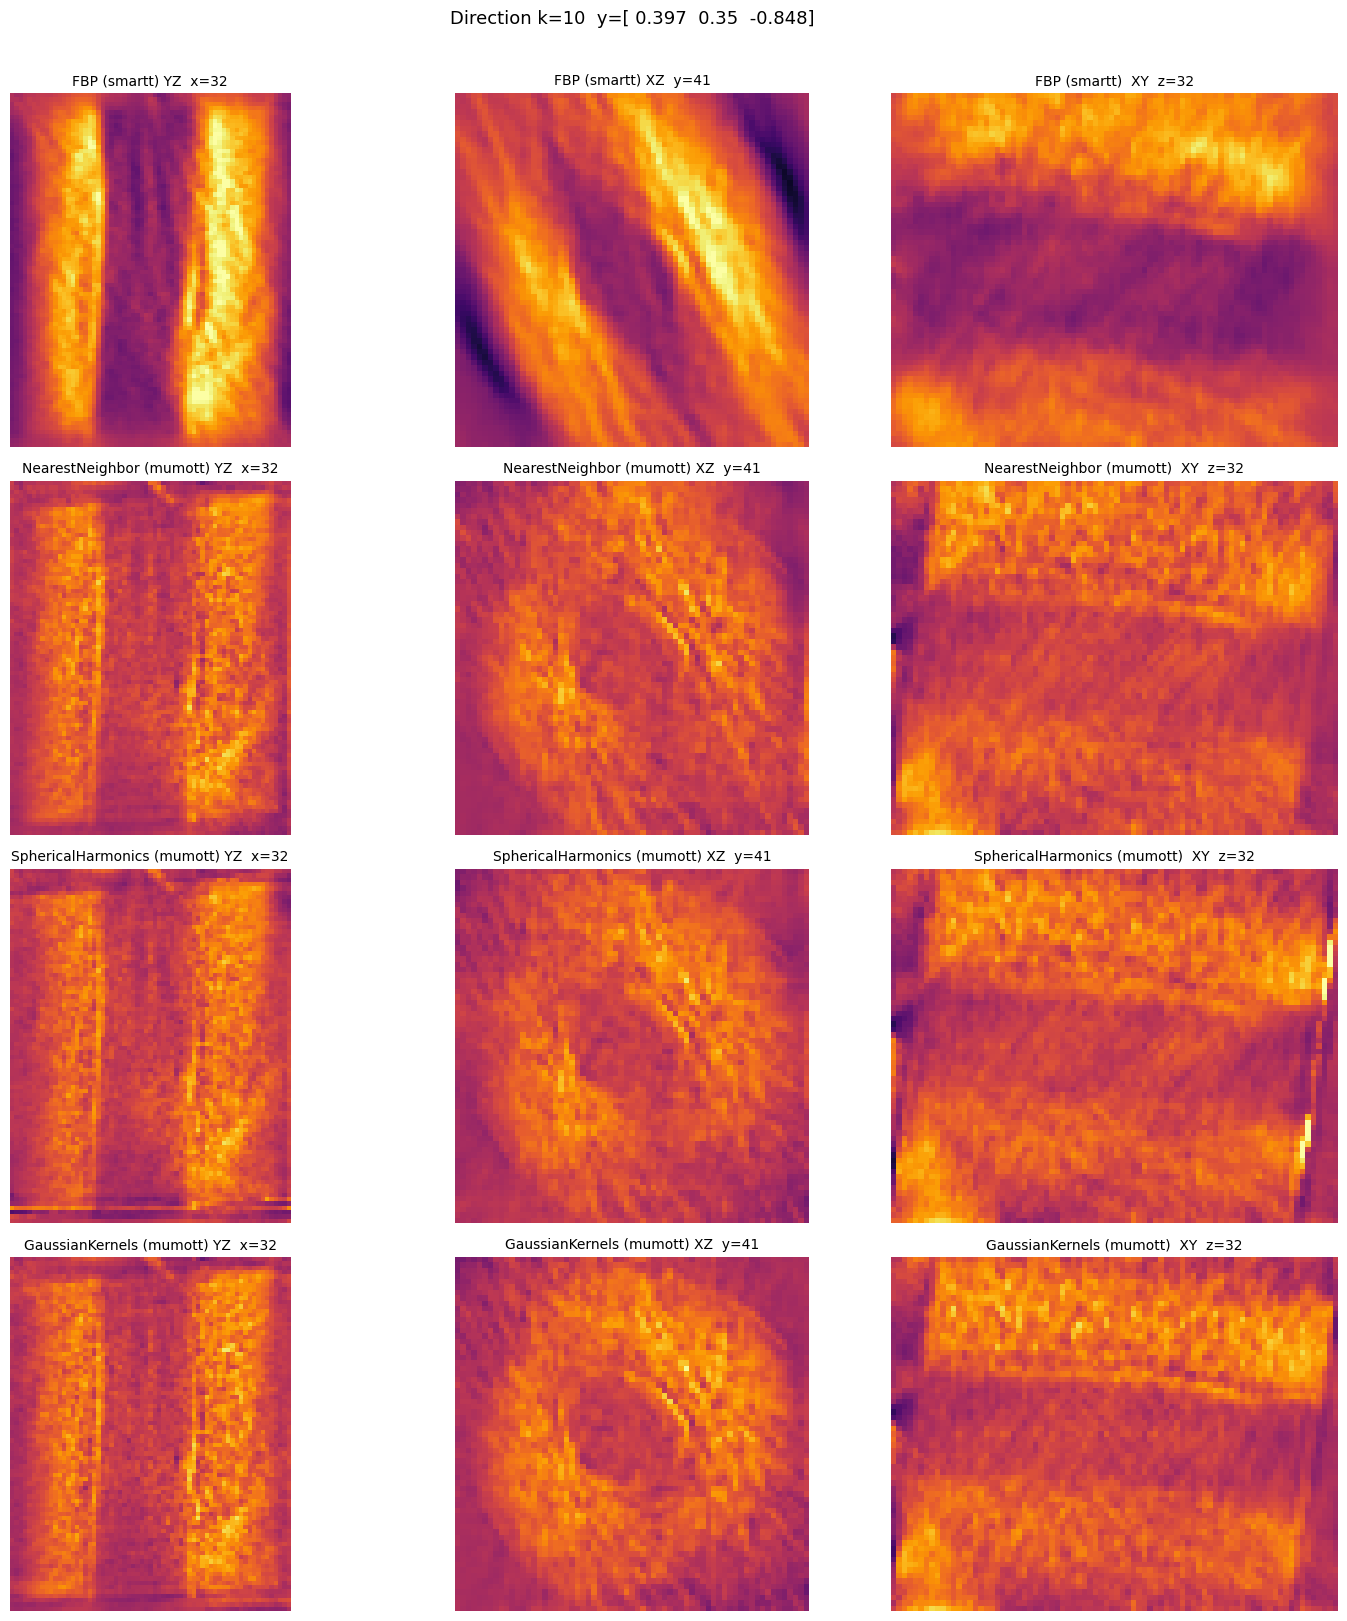

In [93]:
K_INSPECT = 10   # change to inspect a different direction

r_fbp_k = recon_fbp_np[K_INSPECT]
vmin_k  = r_fbp_k.min()
vmax_k  = np.percentile(r_fbp_k, 99.5)

fig, axes = plt.subplots(n_methods, 3, figsize=(15, 4 * n_methods))
for row, (name, recon) in enumerate(reconstructions.items()):
    vol    = recon[K_INSPECT]
    slices = [vol[mid_x, :, :], vol[:, mid_y, :], vol[:, :, mid_z]]
    titles = [f'{name} YZ  x={mid_x}', f'{name} XZ  y={mid_y}', f'{name}  XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin_k, vmax=vmax_k)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=10)
    

# plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Intensity')
plt.suptitle(
    f'Direction k={K_INSPECT}  y={np.round(y_directions[K_INSPECT], 3)}',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

### 5.3 Difference maps (method − FBP)

Diverging colour map centred at zero; symmetric limits at the 98th percentile of |diff|.
Blue = method gives less intensity than FBP; red = more.

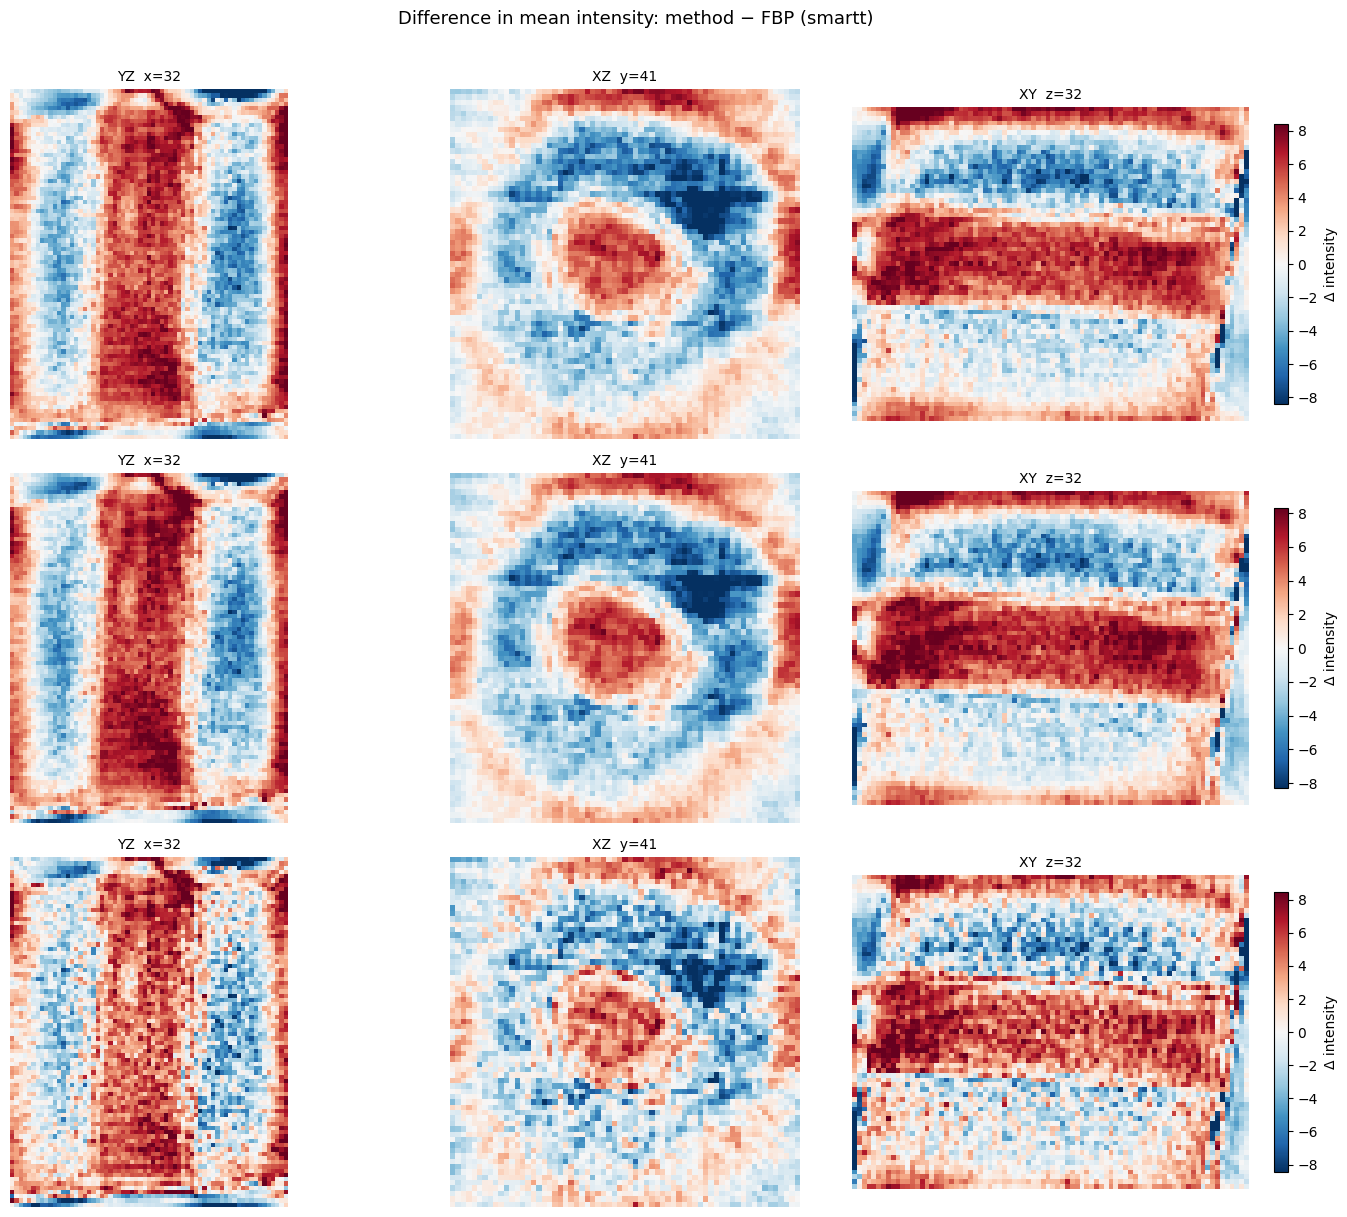

In [94]:
others = {k: v for k, v in reconstructions.items() if k != 'FBP (smartt)'}
n_others = len(others)

fig, axes = plt.subplots(n_others, 3, figsize=(15, 4 * n_others))
if n_others == 1:
    axes = axes[np.newaxis]

for row, (name, recon) in enumerate(others.items()):
    diff   = recon.mean(axis=0) - mean_fbp
    absmax = np.percentile(np.abs(diff), 98)
    slices = [diff[mid_x, :, :], diff[:, mid_y, :], diff[:, :, mid_z]]
    titles = [f'YZ  x={mid_x}', f'XZ  y={mid_y}', f'XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='RdBu_r', vmin=-absmax, vmax=absmax)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(f'{name}\n− FBP', fontsize=9)
    plt.colorbar(im, ax=axes[row, 2], shrink=0.8, label='Δ intensity')

plt.suptitle('Difference in mean intensity: method − FBP (smartt)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.4 Missing-cone visualisation in Fourier space

For a sub-CT at direction `y_k`, only beams orthogonal to `y_k` are used.  Fourier frequencies
along `y_k` have no contributing projections and remain unrecovered — the *missing cone*.
This appears as suppressed power (dark stripes) in the log-magnitude FFT of the sub-volume.

Iterative methods (NN, SH, GK) are expected to exhibit the same cone unless explicitly
constrained; FBP is particularly prone to streak artefacts from missing frequencies.

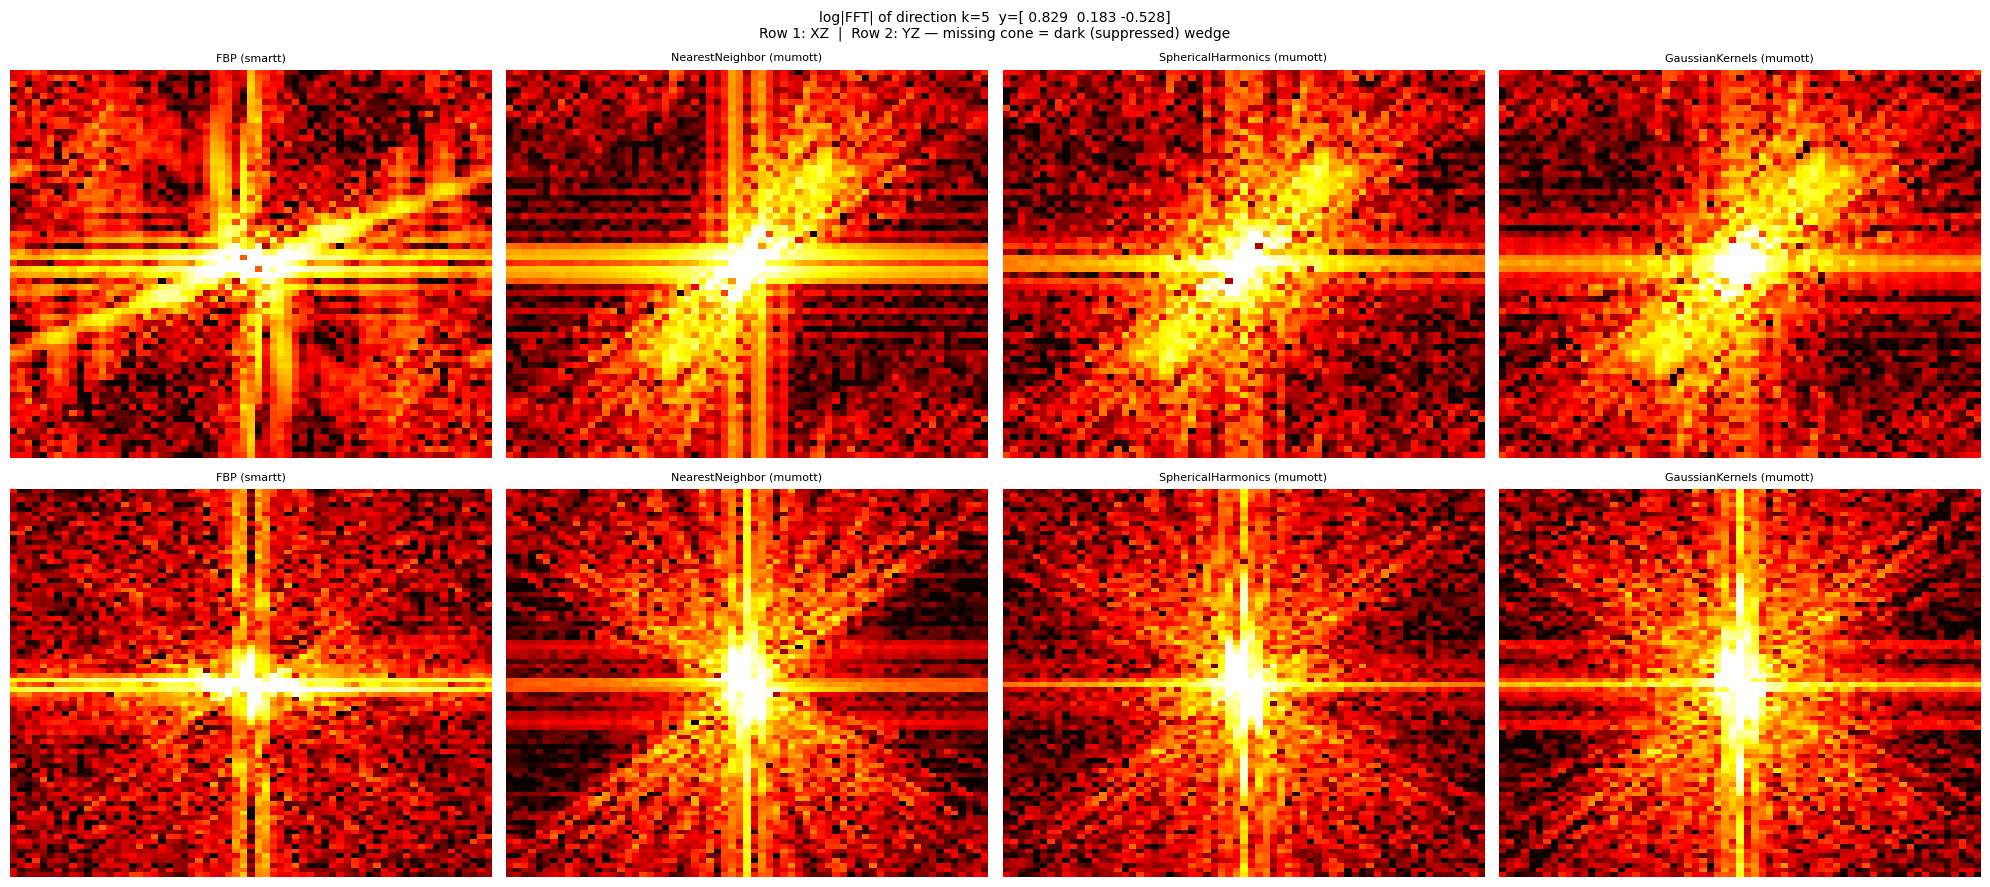

In [68]:
# Log-magnitude FFT central slices for direction K_INSPECT
fig, axes = plt.subplots(2, n_methods, figsize=(5 * n_methods, 9))

for col, (name, recon) in enumerate(reconstructions.items()):
    vol_k   = recon[K_INSPECT].astype(np.float32)
    fft_vol = np.abs(np.fft.fftshift(np.fft.fftn(vol_k)))
    log_fft = np.log1p(fft_vol)
    fx, fy, fz = [s // 2 for s in fft_vol.shape]

    # Row 0: XZ plane (kx–kz), Row 1: YZ plane (ky–kz)
    for row, (sl, ylabel) in enumerate([
        (log_fft[:, fy, :], 'kx'),
        (log_fft[fx, :, :], 'ky'),
    ]):
        axes[row, col].imshow(sl, cmap='hot', aspect='auto',
                              vmin=np.percentile(sl, 5), vmax=np.percentile(sl, 99))
        axes[row, col].set_xlabel('kz', fontsize=8)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(ylabel, fontsize=8)
        axes[row, col].set_title(name, fontsize=8, wrap=True)

plt.suptitle(
    f'log|FFT| of direction k={K_INSPECT}  y={np.round(y_directions[K_INSPECT], 3)}\n'
    'Row 1: XZ  |  Row 2: YZ — missing cone = dark (suppressed) wedge',
    fontsize=10,
)
plt.tight_layout()
plt.show()

### 5.5 Per-direction mean intensity profile

For each direction k, the spatially-averaged intensity gives a scalar measure of how much
scattering power was reconstructed in that direction.  Comparing profiles across methods
reveals systematic biases (e.g. over-smoothing in SH at high-k directions).

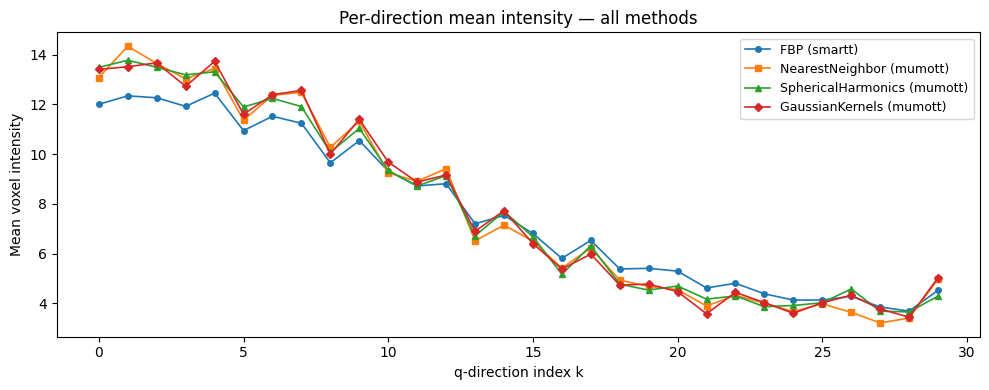

In [75]:
fig, ax = plt.subplots(figsize=(10, 4))
markers = ['o', 's', '^', 'D']
for (name, recon), marker in zip(reconstructions.items(), markers):
    profile = recon.mean(axis=(1, 2, 3))   # (K,) — mean over voxels
    ax.plot(range(K), profile, marker=marker, markersize=4, label=name, linewidth=1.2)

ax.set_xlabel('q-direction index k')
ax.set_ylabel('Mean voxel intensity')
ax.set_title('Per-direction mean intensity — all methods')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. IsoNet Pipeline — Missing-Wedge Correction

Loads the output of `run_pipeline` (`final/` directory) and compares it to the raw FBP.

Set `ISONET_FINAL_DIR` to the `final/` subdirectory of the `output_dir` you passed to
`run_pipeline`.  The section is skipped gracefully if the path does not exist yet.

- **6.1** Side-by-side mean-intensity slices: FBP vs IsoNet
- **6.2** Difference map (IsoNet − FBP): what the model filled in
- **6.3** Fourier-space comparison: the dark missing-wedge stripes should shrink
- **6.4** Per-direction profile: directions with large missing wedge should gain intensity

In [97]:
import pathlib, sys
sys.path.insert(0, '/myhome/smartt')

# ── Point this to your pipeline output_dir / 'final' ─────────────────────────
# ISONET_FINAL_DIR = pathlib.Path('/myhome/data/smartt/shared/results/saxs_isonet/final')
ISONET_FINAL_DIR = pathlib.Path('/myhome/data/smartt/shared/isonet_results/frogbone/round_01_volumes')
ALPHA_DEG        = 45.0    # must match what was passed to run_pipeline
# ─────────────────────────────────────────────────────────────────────────────

if not ISONET_FINAL_DIR.exists():
    print(f'[SKIP] {ISONET_FINAL_DIR} does not exist yet.')
    print('Run run_pipeline(...) first and set ISONET_FINAL_DIR above.')
    ISONET_AVAILABLE = False
else:
    vol_paths = sorted(ISONET_FINAL_DIR.glob('vol_*.npy'))
    if len(vol_paths) != K:
        print(f'[WARN] Found {len(vol_paths)} volumes, expected K={K}. Check ISONET_FINAL_DIR.')
        ISONET_AVAILABLE = False
    else:
        recon_isonet = np.stack([np.load(p) for p in vol_paths], axis=0)  # (K, X, Y, Z)
        print(f'Loaded IsoNet output: shape={recon_isonet.shape}  '
              f'range=[{recon_isonet.min():.3e}, {recon_isonet.max():.3e}]')
        ISONET_AVAILABLE = True

from smartt.saxs_isonet.wedge import all_missing_arcs, goniometer_axis_for_half_space
G_AXIS = goniometer_axis_for_half_space(HALF_SPACE)
arcs_deg = np.degrees(all_missing_arcs(y_directions, ALPHA_DEG, G_AXIS))

Loaded IsoNet output: shape=(30, 65, 82, 65)  range=[-2.916e+02, 9.805e+02]


In [111]:
reconstructions = {
    'FBP (smartt)':               recon_fbp_np,
    'ISONET (smartt)':      recon_isonet,
    'NearestNeighbor (mumott)':   recon_nn,
}

vol_shape = recon_fbp_np.shape[1:]
mid_x, mid_y, mid_z = [s // 2 for s in vol_shape]
print('Volume shape:', vol_shape)
print(f'Central slices: x={mid_x}, y={mid_y}, z={mid_z}')


Volume shape: (65, 82, 65)
Central slices: x=32, y=41, z=32


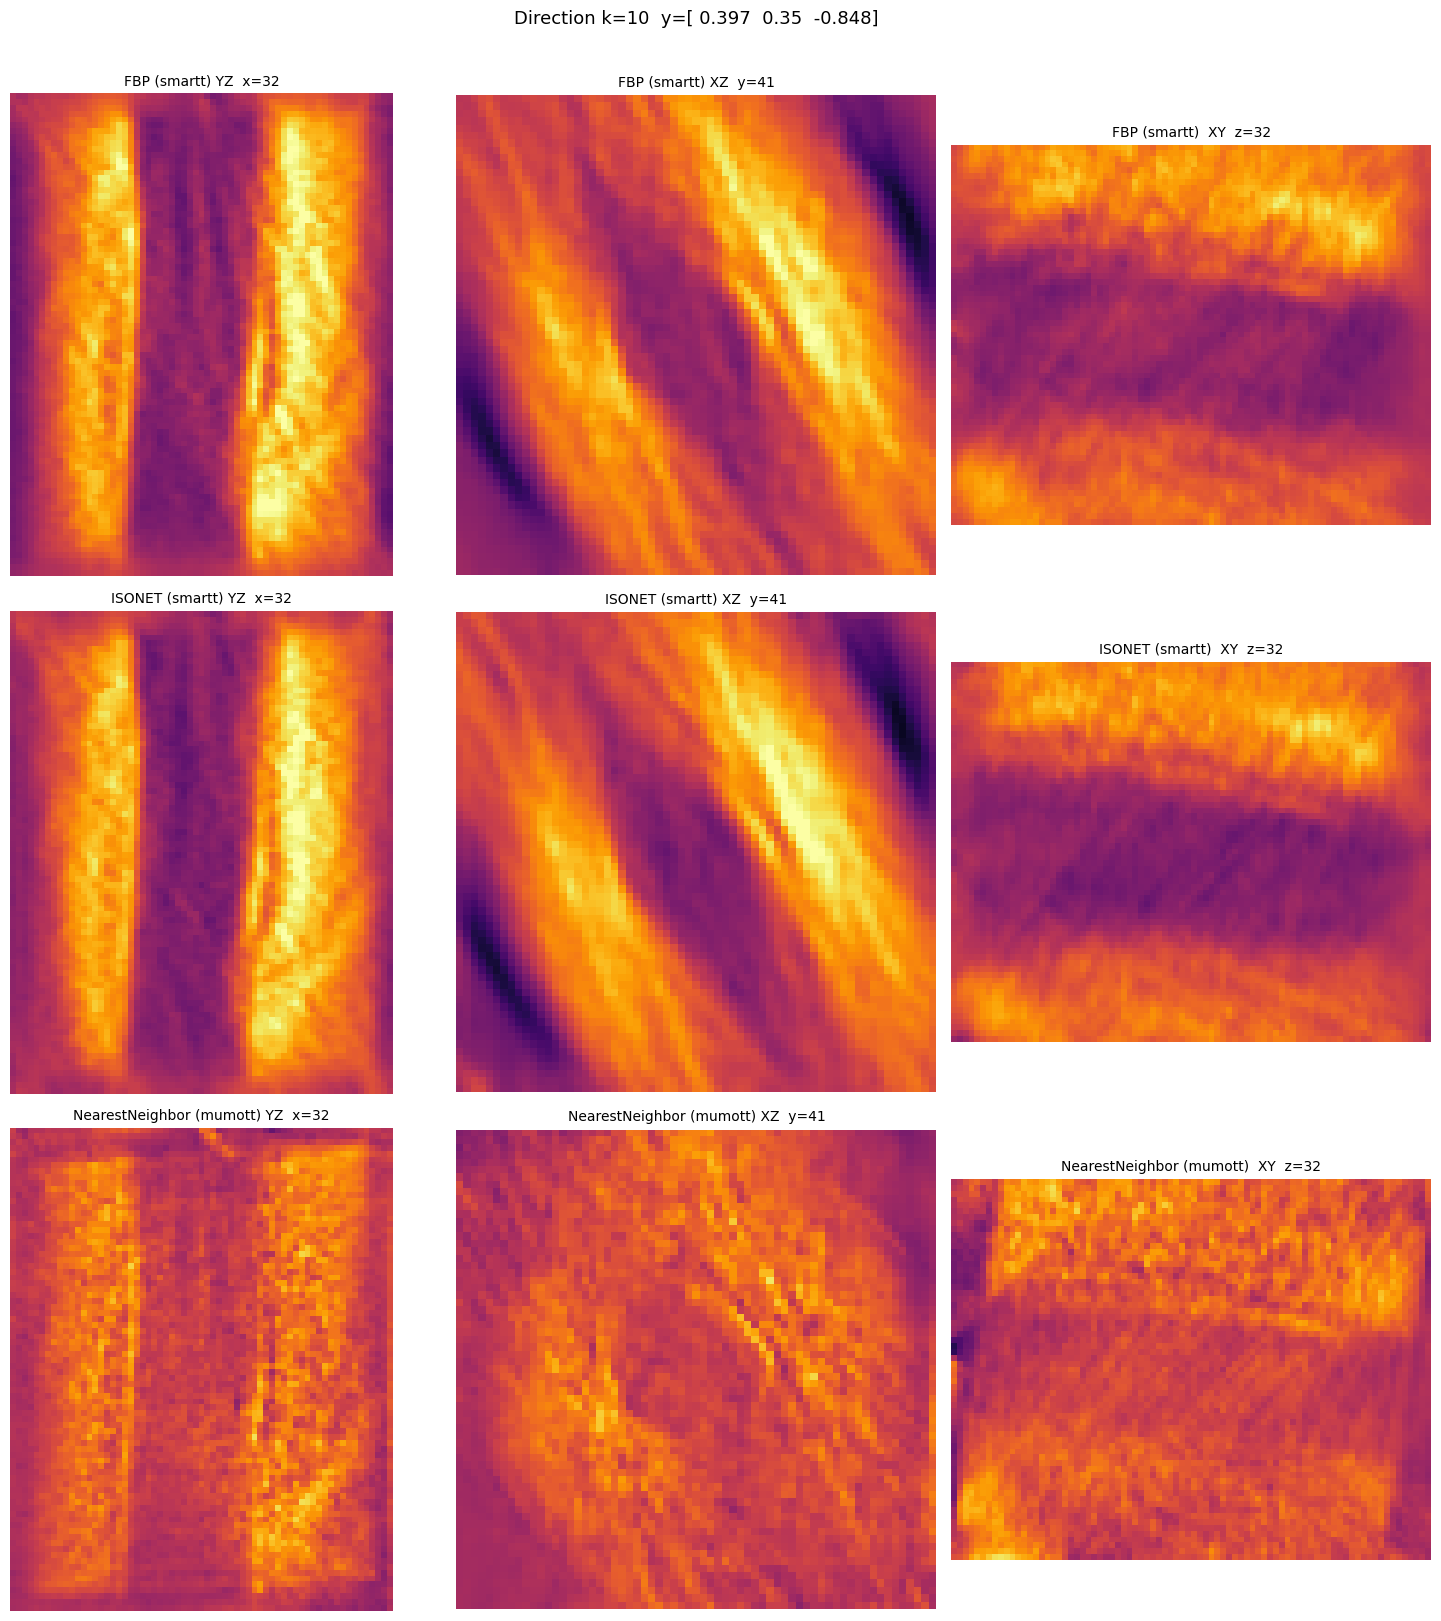

In [112]:
K_INSPECT = 10   # change to inspect a different direction

r_fbp_k = recon_fbp_np[K_INSPECT]
vmin_k  = r_fbp_k.min()
vmax_k  = np.percentile(r_fbp_k, 99.5)

fig, axes = plt.subplots(len(reconstructions), 3, figsize=(15, 4 * n_methods))
for row, (name, recon) in enumerate(reconstructions.items()):
    vol    = recon[K_INSPECT]
    slices = [vol[mid_x, :, :], vol[:, mid_y, :], vol[:, :, mid_z]]
    titles = [f'{name} YZ  x={mid_x}', f'{name} XZ  y={mid_y}', f'{name}  XY  z={mid_z}']
    for col, (sl, title) in enumerate(zip(slices, titles)):
        im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin_k, vmax=vmax_k)
        axes[row, col].axis('off')
        axes[row, col].set_title(title, fontsize=10)
    axes[row, 0].set_ylabel(name, fontsize=10)
    

# plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Intensity')
plt.suptitle(
    f'Direction k={K_INSPECT}  y={np.round(y_directions[K_INSPECT], 3)}',
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_43501/3380430092.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


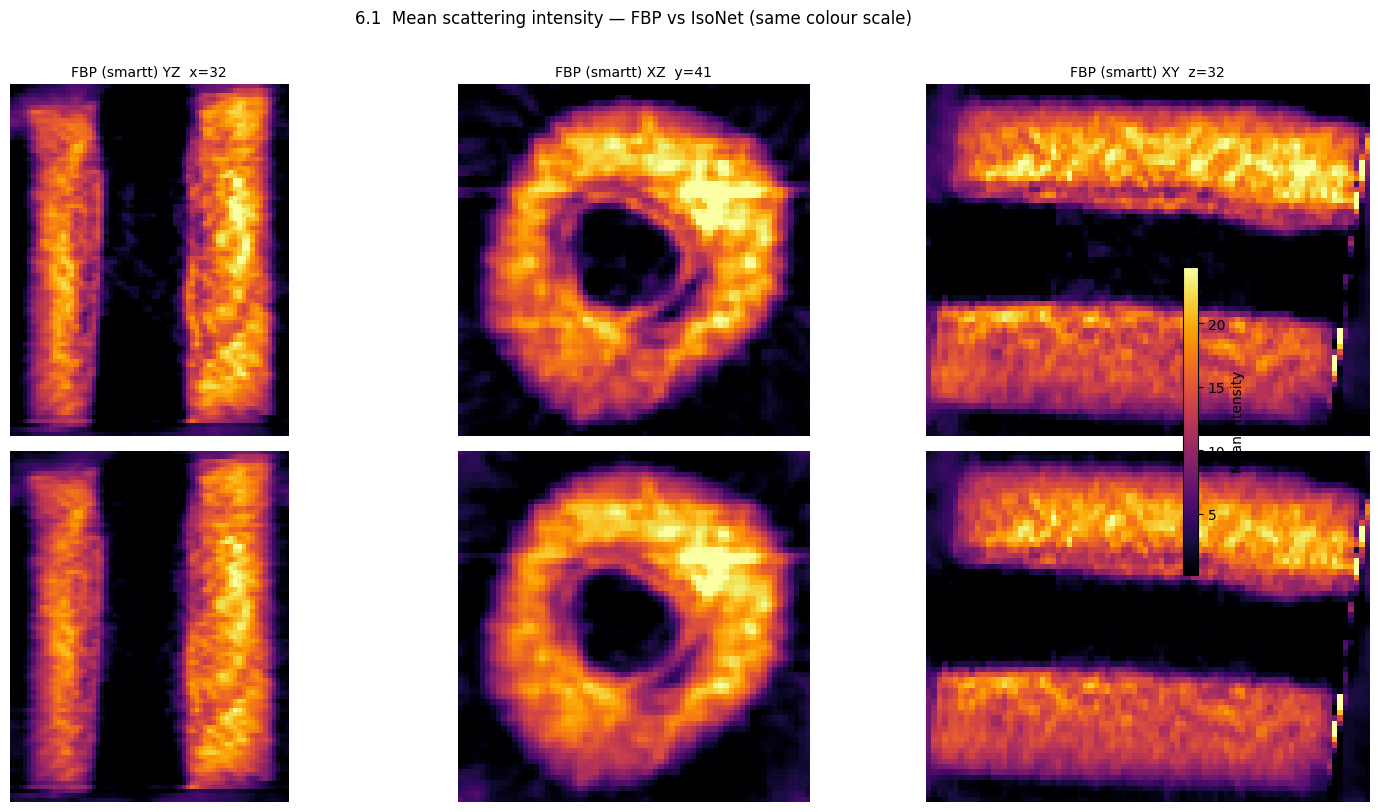

In [102]:
if not ISONET_AVAILABLE:
    print('[SKIP] IsoNet output not available.')
else:
    # ── 6.1  Side-by-side mean-intensity slices: FBP vs IsoNet ───────────────
    pair = {'FBP (smartt)': recon_fbp_np, 'IsoNet (smartt)': recon_isonet}

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for row, (name, recon) in enumerate(pair.items()):
        mean_vol = recon.mean(axis=0)
        for col, (sl, title) in enumerate(zip(
            [mean_vol[mid_x, :, :], mean_vol[:, mid_y, :], mean_vol[:, :, mid_z]],
            [f'{name} YZ  x={mid_x}', f'{name} XZ  y={mid_y}', f'{name} XY  z={mid_z}'],
        )):
            im = axes[row, col].imshow(sl, cmap='inferno', vmin=vmin, vmax=vmax)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(title, fontsize=10)
        axes[row, 0].set_ylabel(name, fontsize=10)
    plt.colorbar(im, ax=axes[:, 2], shrink=0.5, label='Mean intensity')
    plt.suptitle('6.1  Mean scattering intensity — FBP vs IsoNet (same colour scale)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_43501/2099236613.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


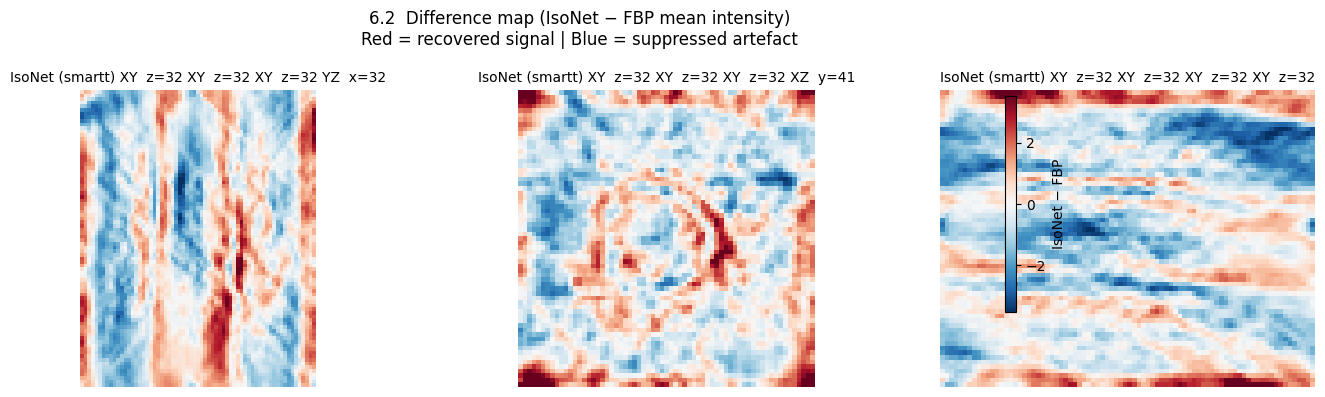

In [105]:
if not ISONET_AVAILABLE:
    print('[SKIP] IsoNet output not available.')
else:
    # ── 6.2  Difference map: IsoNet − FBP ────────────────────────────────────
    # Positive (red)  = IsoNet adds intensity the FBP was missing.
    # Negative (blue) = IsoNet suppresses FBP artefacts.
    diff_mean = recon_isonet.mean(axis=0) - mean_fbp
    absmax    = np.percentile(np.abs(diff_mean), 98)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, sl, title in zip(axes,
        [diff_mean[mid_x, :, :], diff_mean[:, mid_y, :], diff_mean[:, :, mid_z]],
        [f'{title} YZ  x={mid_x}', f'{title} XZ  y={mid_y}', f'{title} XY  z={mid_z}'],
    ):
        im = ax.imshow(sl, cmap='RdBu_r', vmin=-absmax, vmax=absmax)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.colorbar(im, ax=axes, shrink=0.7, label='IsoNet − FBP')
    plt.suptitle('6.2  Difference map (IsoNet − FBP mean intensity)\n'
                 'Red = recovered signal | Blue = suppressed artefact',
                 fontsize=12)
    plt.tight_layout()
    plt.show()

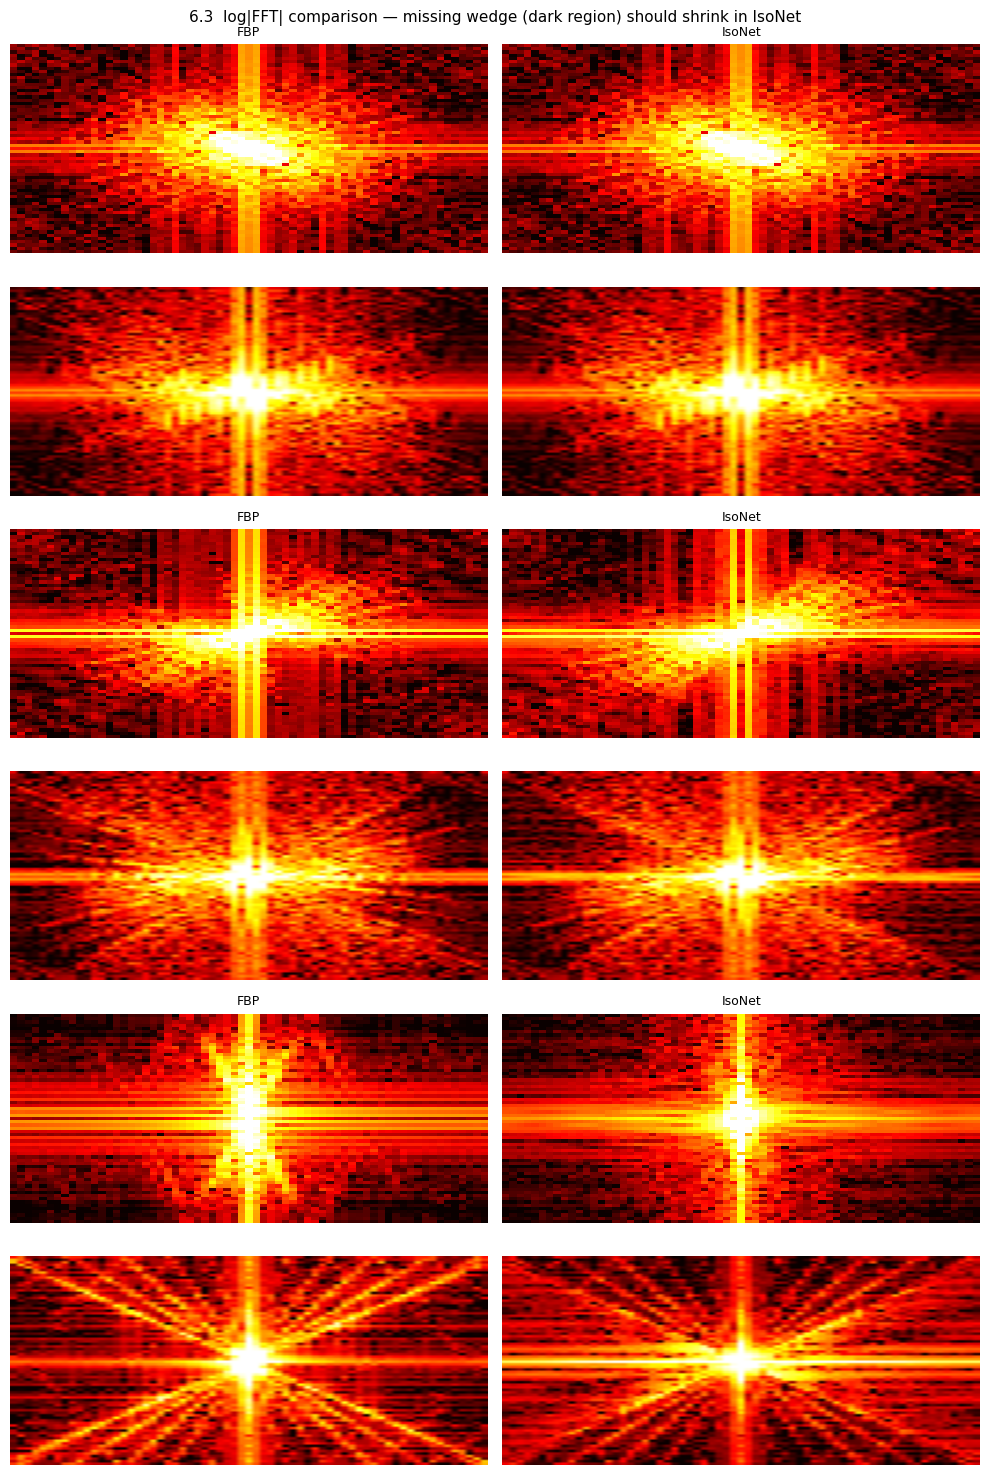

In [100]:
if not ISONET_AVAILABLE:
    print('[SKIP] IsoNet output not available.')
else:
    # ── 6.3  Fourier-space comparison — the key missing-wedge diagnostic ──────
    # For each inspected direction the dark wedge in log|FFT| should be narrower
    # in the IsoNet output than in the raw FBP.
    # Show directions with different missing-wedge sizes for context.
    sort_idx  = np.argsort(arcs_deg)           # ascending: smallest wedge first
    k_small   = int(sort_idx[0])               # near-pole: smallest missing wedge
    k_medium  = int(sort_idx[len(sort_idx)//2])
    k_large   = int(sort_idx[-1])              # near-equator: largest missing wedge
    k_show    = [k_small, k_medium, k_large]
    k_labels  = ['small wedge\n(near pole)', 'medium wedge', 'large wedge\n(near equator)']

    fig, axes = plt.subplots(len(k_show) * 2, 2, figsize=(10, 5 * len(k_show)))

    for row_base, (k, klabel) in enumerate(zip(k_show, k_labels)):
        for col, (name, recon) in enumerate([('FBP', recon_fbp_np), ('IsoNet', recon_isonet)]):
            vol_k   = recon[k].astype(np.float32)
            fft_vol = np.abs(np.fft.fftshift(np.fft.fftn(vol_k)))
            log_fft = np.log1p(fft_vol)
            fx, fy, fz = [s // 2 for s in fft_vol.shape]

            # Two Fourier slices: XZ and YZ
            for sub_row, (sl, plane) in enumerate([(log_fft[:, fy, :], 'XZ'), (log_fft[fx, :, :], 'YZ')]):
                ax = axes[row_base * 2 + sub_row, col]
                vlo, vhi = np.percentile(sl, [5, 99])
                ax.imshow(sl, cmap='hot', aspect='auto', vmin=vlo, vmax=vhi)
                ax.axis('off')
                if sub_row == 0:
                    ax.set_title(f'{name}', fontsize=9)
                if col == 0:
                    ax.set_ylabel(
                        f'k={k}  {klabel}\nmissing={arcs_deg[k]:.0f}°\n({plane})',
                        fontsize=7,
                    )

    plt.suptitle('6.3  log|FFT| comparison — missing wedge (dark region) should shrink in IsoNet',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

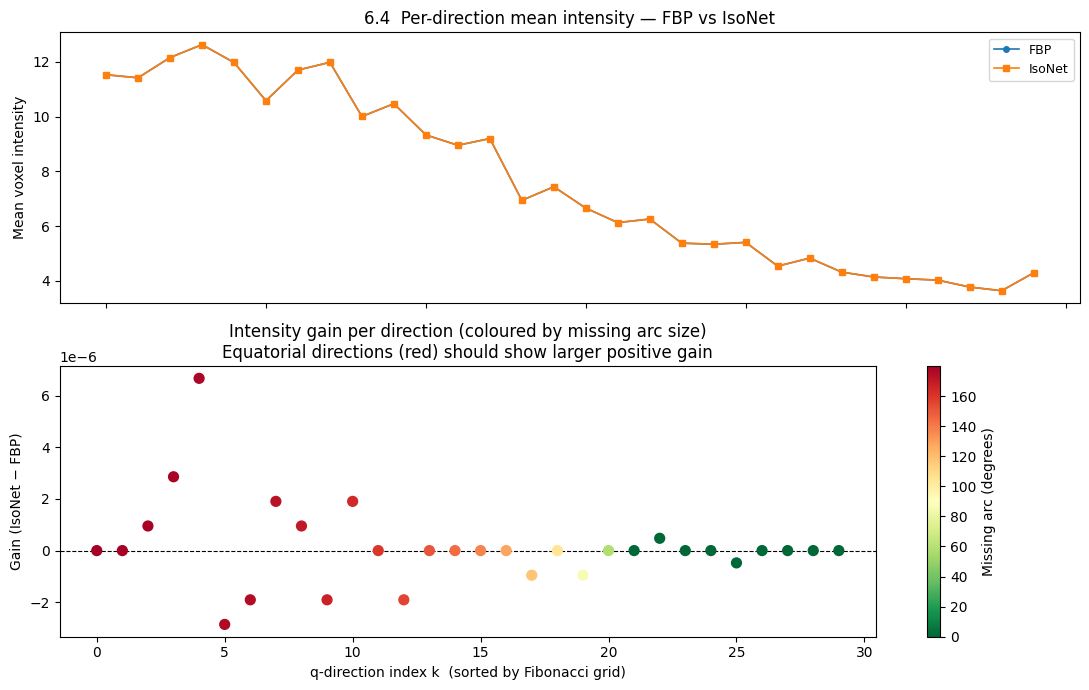

Mean gain  : +1.589e-07
Max gain   : +6.676e-06  (k=4, arc=177.4°)
Correlation(missing_arc, gain): 0.140  (positive → equatorial dirs gain more, as expected)


In [101]:
if not ISONET_AVAILABLE:
    print('[SKIP] IsoNet output not available.')
else:
    # ── 6.4  Per-direction mean intensity: FBP vs IsoNet vs missing arc ───────
    # If the pipeline recovers missing-wedge content, directions with a large
    # missing arc (equatorial) should gain more intensity than near-pole directions.
    fbp_profile    = recon_fbp_np.mean(axis=(1, 2, 3))    # (K,)
    isonet_profile = recon_isonet.mean(axis=(1, 2, 3))    # (K,)
    gain           = isonet_profile - fbp_profile          # (K,)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    # Top: absolute profiles
    axes[0].plot(range(K), fbp_profile,    'o-', ms=4, lw=1.2, label='FBP')
    axes[0].plot(range(K), isonet_profile, 's-', ms=4, lw=1.2, label='IsoNet')
    axes[0].set_ylabel('Mean voxel intensity')
    axes[0].set_title('6.4  Per-direction mean intensity — FBP vs IsoNet')
    axes[0].legend(fontsize=9)

    # Bottom: gain coloured by missing arc size
    sc = axes[1].scatter(range(K), gain, c=arcs_deg, cmap='RdYlGn_r', s=50, zorder=3)
    axes[1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1].set_xlabel('q-direction index k  (sorted by Fibonacci grid)')
    axes[1].set_ylabel('Gain (IsoNet − FBP)')
    axes[1].set_title('Intensity gain per direction (coloured by missing arc size)\n'
                      'Equatorial directions (red) should show larger positive gain')
    plt.colorbar(sc, ax=axes[1], label='Missing arc (degrees)')

    plt.tight_layout()
    plt.show()

    # Summary statistics
    print(f'Mean gain  : {gain.mean():+.3e}')
    print(f'Max gain   : {gain.max():+.3e}  (k={gain.argmax()}, arc={arcs_deg[gain.argmax()]:.1f}°)')
    corr = np.corrcoef(arcs_deg, gain)[0, 1]
    print(f'Correlation(missing_arc, gain): {corr:.3f}  '
          f'(positive → equatorial dirs gain more, as expected)')